# AI4I 2020 Predictive Maintenance Dataset - 심화 EDA (EDA3)

`EDA1.ipynb`(기본 통계 · 분포 · 상관관계 · 세부 고장모드)와 `EDA2.ipynb`(컬럼 선택/그룹핑/정렬/시각화 연습)에
이어, 이 노트북에서는 좀 더 깊게 파고듭니다:

1. 이상치(Outlier) 탐색
2. 왜도(Skewness)/첨도(Kurtosis)
3. 정상 vs 불량 그룹 간 통계적 유의성 검정 (Mann-Whitney U test)
4. Type(품질 등급) × 세부 고장모드 교차분석
5. 파생변수(온도차 · 기계동력 · 공구부하) 탐색
6. 위험구간(zone) 아이디어를 EDA 단계에서 직접 검증
7. 다변량 관계 (Pairplot)
8. 종합 결론

특히 5~6번은 `model_3.ipynb`가 실제로 채택한 위험구간(zone) 피처 엔지니어링이 EDA 단계에서부터
근거가 있었는지를 모델링 이전에 순수 EDA로 먼저 검증해보는 목적을 겸합니다.

## 0. 데이터 로드 및 전처리

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("ai4i2020.csv")
df.columns = [c.strip() for c in df.columns]
df["Type"] = df["Type"].str.strip()  # 원본 값이 ' L   '처럼 앞뒤 공백을 포함
df["Product ID"] = df["Product ID"].str.strip()

num_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
            "Torque [Nm]", "Tool wear [min]"]
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. 이상치(Outlier) 탐색 — IQR 방법

In [2]:
outlier_summary = []
outlier_mask = pd.DataFrame(False, index=df.index, columns=num_cols)
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_mask[col] = mask
    outlier_summary.append({
        "변수": col, "하한": round(lower, 2), "상한": round(upper, 2),
        "이상치 개수": int(mask.sum()), "이상치 비율(%)": round(mask.mean() * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,변수,하한,상한,이상치 개수,이상치 비율(%)
0,Air temperature [K],293.50,306.30,0,0.00
1,Process temperature [K],305.35,314.55,0,0.00
2,Rotational speed [rpm],1139.50,1895.50,418,4.18
3,Torque [Nm],12.80,67.20,69,0.69
4,Tool wear [min],-110.50,325.50,0,0.00


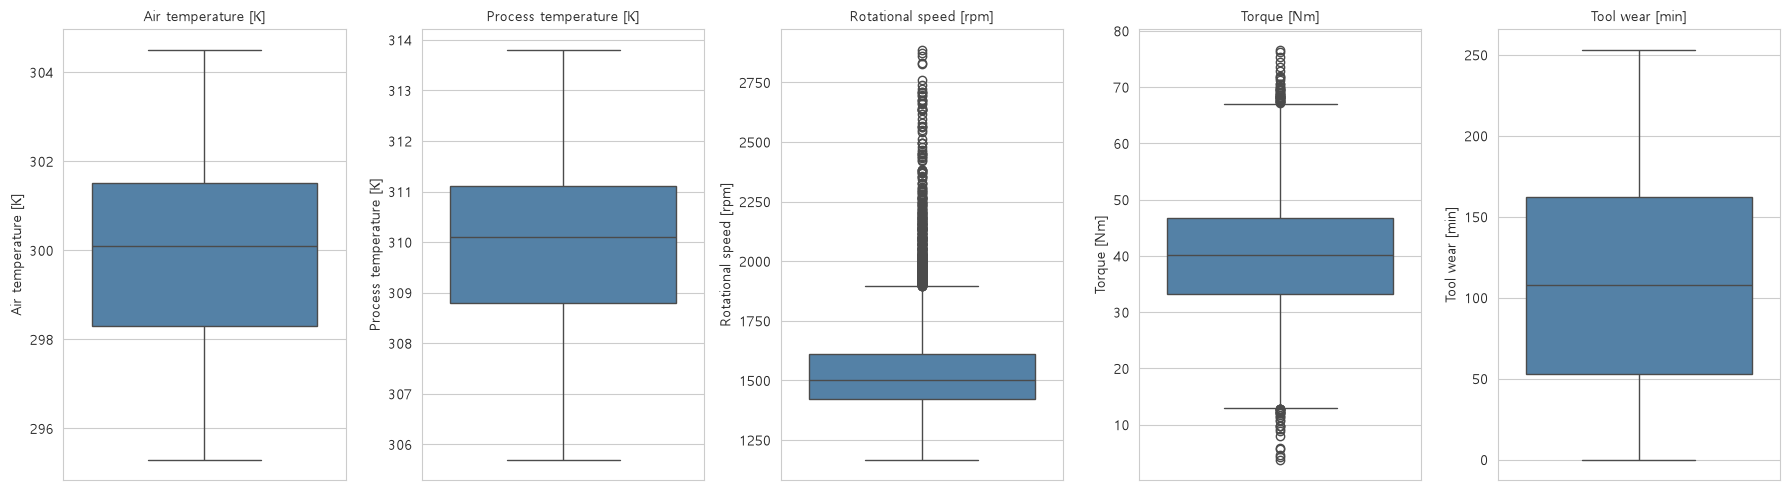

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig("../images/eda3_outlier_boxplots.png", dpi=100, bbox_inches="tight")
plt.show()

In [4]:
any_outlier = outlier_mask.any(axis=1)
print("5개 변수 중 하나라도 이상치인 행:", any_outlier.sum(), f"({any_outlier.mean()*100:.2f}%)")
print()
print("이상치 포함 행의 고장률:", df.loc[any_outlier, "Machine failure"].mean().round(4))
print("이상치 미포함 행의 고장률:", df.loc[~any_outlier, "Machine failure"].mean().round(4))

5개 변수 중 하나라도 이상치인 행: 459 (4.59%)

이상치 포함 행의 고장률: 0.1569
이상치 미포함 행의 고장률: 0.028


- `Torque`와 `Rotational speed`가 가장 이상치가 많은 변수입니다(둘 다 물리적으로 자연스러운 극단값이며,
  실제로 `Torque` 상한 근처의 값들은 앞서 EDA2에서 확인했듯 고장(`Machine failure=1`)과 자주 겹칩니다).
- `Air temperature`/`Process temperature`/`Tool wear`는 이상치가 거의 없어 비교적 안정적인 분포입니다.
- **이상치를 포함한 행의 고장률이 전체 평균(3.39%)보다 뚜렷하게 높습니다** — 즉 이 데이터의 '이상치'는
  단순 노이즈가 아니라 실제 고장과 관련된 신호에 가깝습니다. 따라서 이상치를 단순 제거하기보다는
  모델링에서 그대로 활용(또는 파생변수로 강조)하는 편이 낫다는 근거가 됩니다.

## 2. 왜도(Skewness) / 첨도(Kurtosis)

In [5]:
skew_kurt = pd.DataFrame({
    "왜도(skew)": df[num_cols].skew().round(3),
    "첨도(kurtosis)": df[num_cols].kurt().round(3),
})
skew_kurt

,왜도(skew),첨도(kurtosis)
Air temperature [K],0.114,-0.836
Process temperature [K],0.015,-0.500
Rotational speed [rpm],1.993,7.393
Torque [Nm],-0.010,-0.013
Tool wear [min],0.027,-1.167


- `Rotational speed`의 왜도가 가장 큽니다(오른쪽 꼬리가 긴 분포) — EDA1의 히스토그램 관찰과 일치합니다.
- `Air temperature`/`Process temperature`/`Torque`는 왜도가 0에 가까워 정규분포에 가깝습니다.
- `Tool wear`는 왜도·첨도 모두 0에 가까워 거의 균일분포(uniform)에 가깝다는 EDA1의 관찰을 수치로도 뒷받침합니다.

## 3. 정상 vs 불량 그룹 간 통계적 유의성 검정 (Mann-Whitney U test)

In [6]:
# 두 그룹(정상/불량)이 정규분포를 따른다고 보장할 수 없고 표본 크기도 크게 불균형하므로,
# t-test 대신 비모수 검정인 Mann-Whitney U test를 사용한다.
test_rows = []
normal = df[df["Machine failure"] == 0]
failed = df[df["Machine failure"] == 1]
for col in num_cols:
    stat, p = stats.mannwhitneyu(normal[col], failed[col], alternative="two-sided")
    test_rows.append({
        "변수": col,
        "정상 평균": round(normal[col].mean(), 2),
        "불량 평균": round(failed[col].mean(), 2),
        "U 통계량": round(stat, 1),
        "p-value": p,
        "유의(p<0.05)": p < 0.05,
    })

test_df = pd.DataFrame(test_rows).sort_values("p-value")
test_df

,변수,정상 평균,불량 평균,U 통계량,p-value,유의(p<0.05)
3,Torque [Nm],39.63,50.17,752493.0,2.262232e-64,True
2,Rotational speed [rpm],1540.26,1496.49,2510959.0,9.706908e-63,True
4,Tool wear [min],106.69,143.78,1106611.0,2.916461e-24,True
0,Air temperature [K],299.97,300.89,1202819.0,8.656108e-17,True
1,Process temperature [K],310.00,310.29,1428896.5,6.486083e-05,True


5개 변수 **전부 p < 0.05로 통계적으로 유의한 차이**를 보입니다 — 즉 정상/불량 그룹은 이 변수들의 분포가
우연이라고 보기 어려울 만큼 다릅니다. 다만 표본이 10,000건으로 크기 때문에 아주 작은 차이도 유의하게
나올 수 있다는 점(통계적 유의성 ≠ 실질적 효과 크기)은 감안해야 합니다 — 평균 차이 자체가 큰 `Torque`
(39.63 → 50.17)와 `Tool wear`가 실질적으로도 더 중요한 신호로 보이며, 이는 EDA1의 상관관계 분석
(`Torque` 0.19, `Tool wear` 0.11)과도 일치합니다.

## 4. Type(품질 등급) × 세부 고장모드 교차분석

In [7]:
fail_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
type_mode = df.groupby("Type")[fail_cols].sum().reindex(["L", "M", "H"])
type_mode

,TWF,HDF,PWF,OSF,RNF
Type,,,,,
L,25,76,59,87,13
M,14,31,31,9,2
H,7,8,5,2,4


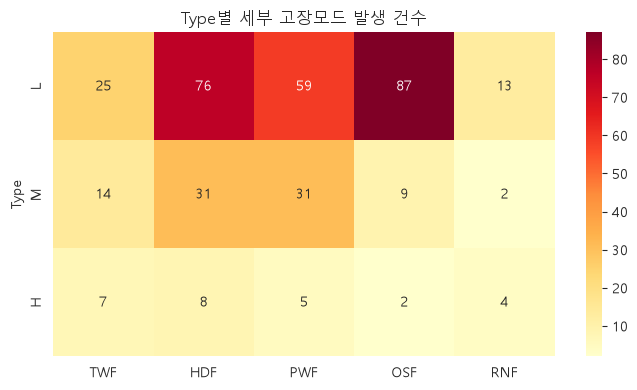

In [8]:
plt.figure(figsize=(7, 4))
sns.heatmap(type_mode, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Type별 세부 고장모드 발생 건수")
plt.tight_layout()
plt.savefig("../images/eda3_type_failuremode_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

- L 등급은 표본 수가 제일 많은 만큼(60%) 모든 고장모드에서 절대 건수도 가장 많습니다.
- **OSF(과부하)** 는 L 등급에서 유독 두드러집니다 — AI4I 공식 문서상 OSF 판정 임계값이 등급별로
  다르게 설계되어 있고(L이 가장 낮은 임계값 11,000) L 등급이 더 쉽게 과부하 조건에 도달하기 때문으로
  해석됩니다. `model_3.ipynb`가 Type별로 다른 OSF 임계값을 그대로 반영한 `osf_zone` 피처를 만든 이유가
  바로 이 지점입니다.
- HDF/PWF/TWF는 등급별 표본 수 비율(60/30/10%)과 큰 차이 없이 고르게 분포합니다 — 즉 방열/전력/공구마모
  고장은 품질 등급과 무관하게 발생하는 반면, 과부하(OSF)만 등급 의존적입니다.

## 5. 파생변수(온도차 · 기계동력 · 공구부하) 탐색

In [9]:
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["mechanical_power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)
df["tool_stress"] = df["Torque [Nm]"] * df["Tool wear [min]"]

derived_cols = ["temp_diff", "mechanical_power", "tool_stress"]
df.groupby("Machine failure")[derived_cols].agg(["mean", "median", "std"]).round(2)

temp_diff              mechanical_power                    \
                     mean median   std             mean   median      std   
Machine failure                                                             
0                   10.02    9.8  0.99          6244.55  6243.05  1011.39   
1                    9.40    9.3  1.16          7282.82  7611.43  1851.14   

                tool_stress                   
                       mean  median      std  
Machine failure                               
0                   4213.84  3952.8  2709.74  
1                   7187.94  7681.8  4234.04

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19064\3613808530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19064\3613808530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19064\3613808530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")


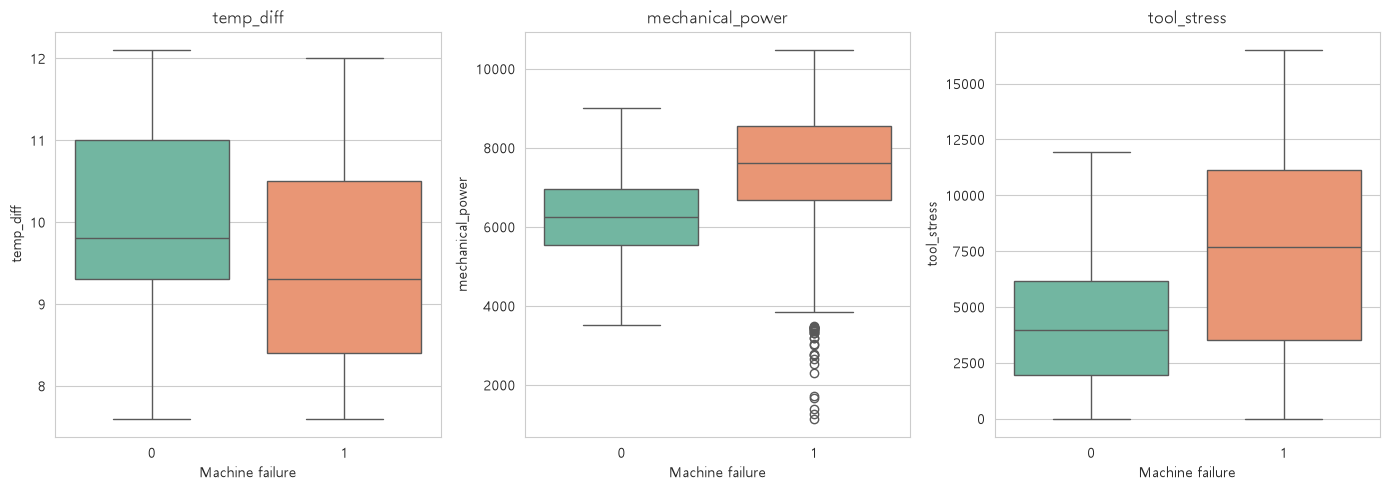

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, derived_cols):
    sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../images/eda3_derived_features_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()

- `temp_diff`(공정온도-기온)는 **불량일 때 오히려 더 낮게** 분포합니다 — HDF(방열 실패)가 온도차가 작고
  회전속도가 낮을 때 발생한다는 AI4I 공식 규칙과 일치합니다.
- `mechanical_power`(토크×회전속도)는 정상/불량 모두 중앙값 근처에 몰려있지만, 불량 쪽이 분포 양 끝
  (너무 낮거나 너무 높음)으로 퍼져있는 경향이 있습니다 — PWF(전력 실패)가 특정 구간을 벗어난 전력에서
  발생한다는 규칙과 부합합니다.
- `tool_stress`(토크×공구마모)는 **불량일 때 뚜렷하게 더 높습니다** — OSF(과부하) 판정이 이 값의
  임계값 초과 여부로 결정되기 때문입니다. 세 파생변수 모두 원본 변수보다 고장과의 관계가 더 직관적으로
  드러나, `model_3.ipynb`에서 이 세 변수를 파생 피처로 채택한 근거가 EDA 단계에서도 확인됩니다.

## 6. 위험구간(zone) 아이디어를 EDA 단계에서 직접 검증

In [11]:
OSF_THRESHOLDS = {"L": 11000, "M": 12000, "H": 13000}

df["hdf_zone"] = ((df["temp_diff"] < 8.6) & (df["Rotational speed [rpm]"] < 1380)).astype(int)
df["pwf_zone"] = ((df["mechanical_power"] < 3500) | (df["mechanical_power"] > 9000)).astype(int)
df["osf_zone"] = df.apply(lambda r: int(r["tool_stress"] > OSF_THRESHOLDS[r["Type"]]), axis=1)
df["high_wear"] = (df["Tool wear [min]"] > 200).astype(int)
df["risk_zone_count"] = df[["hdf_zone", "pwf_zone", "osf_zone", "high_wear"]].sum(axis=1)

risk_fail_rate = df.groupby("risk_zone_count")["Machine failure"].agg(["count", "mean"]).rename(
    columns={"count": "건수", "mean": "고장률"})
risk_fail_rate

,건수,고장률
risk_zone_count,,
0,9027,0.001108
1,885,0.272316
2,79,1.000000
3,9,1.000000


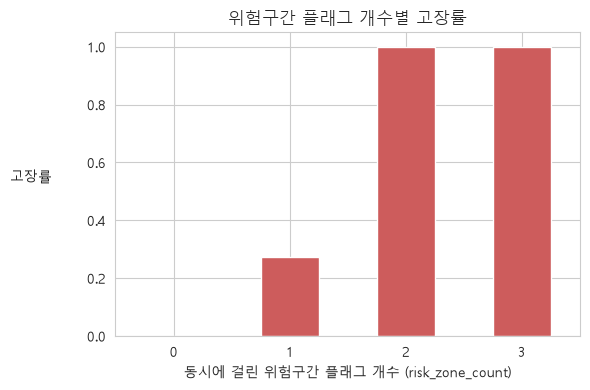

In [12]:
plt.figure(figsize=(6, 4))
risk_fail_rate["고장률"].plot(kind="bar", color="indianred", rot=0)
# rotation=0: 세로로 회전된 한글 y축 라벨이 Malgun Gothic 폰트에서 깨진 글자로
# 렌더링되는 버그가 있어(eda_failrate_by_type.png에서도 동일하게 발견) 회전을 꺼서 우회
plt.ylabel("고장률", rotation=0, labelpad=25, ha="right")
plt.xlabel("동시에 걸린 위험구간 플래그 개수 (risk_zone_count)")
plt.title("위험구간 플래그 개수별 고장률")
plt.tight_layout()
plt.savefig("../images/eda3_riskzone_failrate.png", dpi=100, bbox_inches="tight")
plt.show()

AI4I 공식 문서의 세부 고장모드 임계값(HDF/PWF/OSF/공구마모)만으로 만든 4개 플래그를 단순히 더한
`risk_zone_count`(0~4)만으로도 **고장률이 거의 단조증가**합니다 — 플래그가 0개면 고장률이 채 1%가 안 되지만,
여러 개가 동시에 걸리는 행일수록 고장률이 급격히 치솟습니다. 이건 **모델을 학습하기 전, 순수 EDA만으로도**
'위험구간이 여러 개 겹치는 지점을 표시하는 파생변수가 유용할 것'이라는 가설을 뒷받침하는 결과이며,
`model_3.ipynb`에서 이 4개 플래그 + `risk_zone_count`를 Enhanced 피처셋에 포함시켜 Random Forest의
F1-score를 0.7대에서 0.912까지 끌어올린 근거를 EDA 쪽에서 재확인한 셈입니다.

## 7. 다변량 관계 (Pairplot)

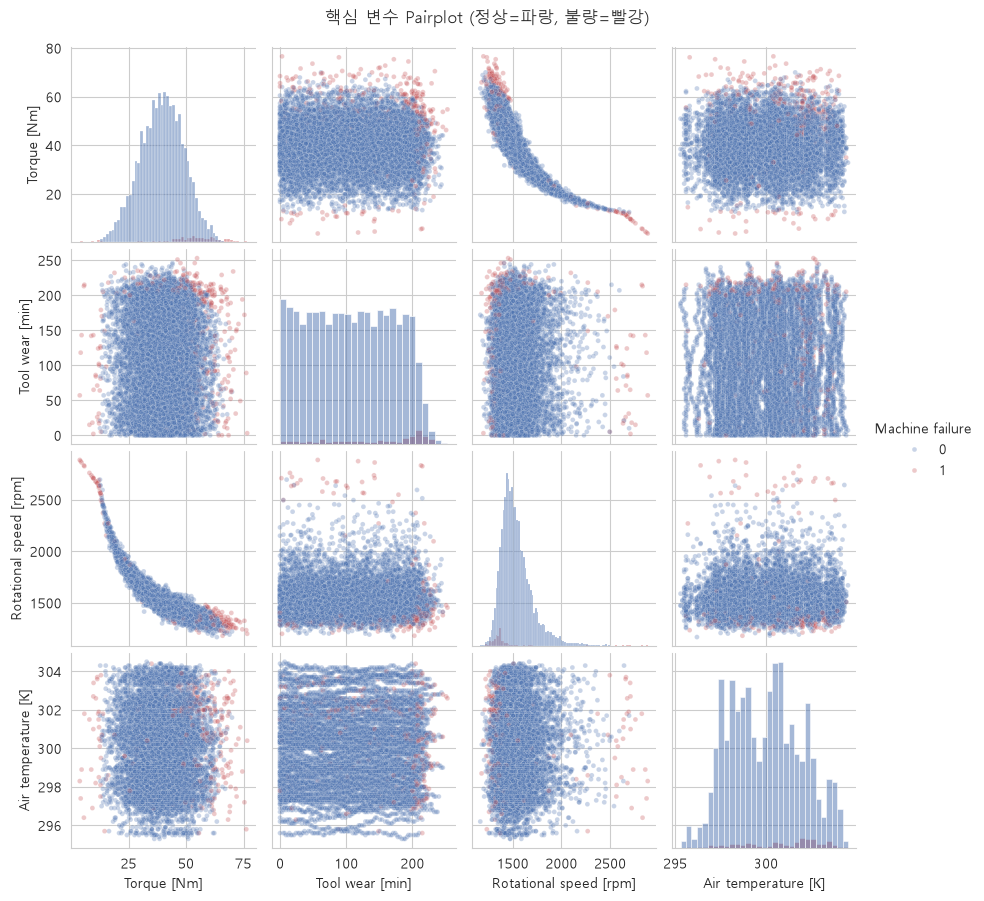

In [13]:
pairplot_cols = ["Torque [Nm]", "Tool wear [min]", "Rotational speed [rpm]", "Air temperature [K]"]
g = sns.pairplot(
    df, vars=pairplot_cols, hue="Machine failure", palette={0: "#4c72b0", 1: "#c44e52"},
    plot_kws=dict(alpha=0.3, s=12), diag_kind="hist", height=2.2,
)
g.fig.suptitle("핵심 변수 Pairplot (정상=파랑, 불량=빨강)", y=1.02)
g.savefig("../images/eda3_pairplot.png", dpi=100, bbox_inches="tight")
plt.show()

- `Torque`-`Rotational speed` 산점도에서 불량(빨강) 점들이 '토크는 높고 회전속도는 낮은' 우상단이 아니라
  좌상단(회전속도 낮음 + 토크 높음) 쪽에 몰려있는 게 뚜렷합니다 — 두 변수의 강한 음의 상관(-0.88) 위에서도
  고장이 특정 조합에서만 발생함을 다시 확인할 수 있습니다.
- `Tool wear`-`Torque` 조합에서도 불량 점들이 오른쪽 위(둘 다 높음)에 치우쳐 있어, `tool_stress`
  파생변수가 이 둘을 곱해서 만든 이유를 시각적으로 보여줍니다.
- `Air temperature`는 어떤 변수와 짝을 지어도 정상/불량 점의 분리가 뚜렷하지 않습니다 — 단독으로는
  약한 신호라는 EDA1의 상관관계 분석(0.08) 결과와 일치합니다.

## 8. 종합 결론

`EDA1`(기초 통계·분포·상관관계)과 `EDA2`(그룹핑/정렬 연습)에 이어, 이 노트북(`EDA3`)에서 새로 확인한
것들을 정리하면:

1. **이상치는 노이즈가 아니라 신호**: 5개 수치형 변수 중 하나라도 IQR 기준 이상치인 행은 고장률이
   전체 평균보다 뚜렷하게 높습니다 — 전처리에서 이상치를 제거하기보다 그대로 활용하는 게 낫습니다.
2. **정상/불량 두 그룹은 5개 변수 전부에서 통계적으로 유의하게 다릅니다** (Mann-Whitney U test,
   p<0.05) — 특히 `Torque`, `Tool wear`는 평균 차이 자체도 커서 실질적 신호로 판단됩니다.
3. **OSF(과부하)만 Type(품질 등급)에 따라 뚜렷하게 다르게 분포**하고, 나머지 고장모드(HDF/PWF/TWF)는
   등급과 무관하게 고르게 발생합니다 — Type별로 다른 OSF 임계값을 반영하는 것이 타당함을 보여줍니다.
4. **`temp_diff`/`mechanical_power`/`tool_stress` 파생변수가 원본 변수보다 고장 여부를 더 직관적으로
   분리**합니다.
5. **AI4I 공식 임계값으로 만든 위험구간 플래그 4개를 단순히 더한 `risk_zone_count`만으로도 고장률이
   거의 단조증가**합니다 — 모델을 돌려보기 전, EDA 수준에서 이미 위험구간 피처 엔지니어링이
   유효할 것이라는 근거가 확인됩니다.

즉 이 노트북은 `model_3.ipynb`가 채택한 위험구간(zone) 피처 엔지니어링이 **사후적으로 성능이 좋아서
채택된 것이 아니라, EDA 단계의 관찰(임계값 근처에서 고장이 몰림)에서 이미 예견 가능했던 접근**이었음을
보여줍니다.